In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

In [44]:
client = bigquery.Client()

query = """
SELECT *
FROM `foreign-trade-brazil.analytics.mart_foreign_trade`
LIMIT 100
"""

df = client.query(query).to_dataframe()

df.head()

c:\Users\gabii\anaconda3\envs\foreign-trade-brazil\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,year,month,country_code,country_name_en,ncm_code,ncm_description_en,value_usd,net_weight_kg,state_code,transportation_mode_code,...,avg_sell_exchange_rate,sitc_subgroup_description,sitc_group_description,sitc_division_description,sitc_section_description,bec_level_3_description_en,bec_level_2_description_en,bec_level_1_description_en,sitc_item_code,bec_level_3_code
0,2021,3,476,Marshall Islands,2013000,"Fresh or chilled bovine meat, boneless",105,11,PA,0,...,5.646148,Carne bovina fresca ou refrigerada,"Carne bovina fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Prepared foods and beverages, mainly for domes...",Consumer goods semi-durable and non-durable,CONSUMER GOODS (BC),01112,324
1,2023,11,476,Marshall Islands,2022090,Other frozen bovine cuts,116,24,PA,0,...,4.898340,Carne bovina congelada,"Carne bovina fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Prepared foods and beverages, mainly for domes...",Consumer goods semi-durable and non-durable,CONSUMER GOODS (BC),01121,324
2,2023,9,434,Liberia,2031900,Other fresh or chilled meat of swine,258,32,PA,0,...,4.936990,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01221,220
3,2023,11,476,Marshall Islands,2031900,Other fresh or chilled meat of swine,728,113,PA,0,...,4.898340,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01221,220
4,2023,4,741,Singapore,2032900,"Other swine meat, frozen",1317,264,PA,0,...,5.019733,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01222,220



### How has Brazilian foreign trade evolved over time?

How did the financial value of exports and imports change between 2021 and 2024?

KPIs

* Total value (USD)
* Annual growth

In [45]:
query = """
SELECT 
year,
month,
type_operation,
SUM(value_usd) as total_value_usd
FROM `foreign-trade-brazil.analytics.mart_foreign_trade`
GROUP BY year, 
month,
type_operation
ORDER BY
year,
month,
type_operation
"""

q1 = client.query(query).to_dataframe()

print(q1.columns.tolist())

['year', 'month', 'type_operation', 'total_value_usd']


c:\Users\gabii\anaconda3\envs\foreign-trade-brazil\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [46]:
q1["total_value_billion_usd"] = q1["total_value_usd"] / 1e9
q1.style.format({
    "total_value_billion_usd": "{:.2f} B"
})

q1.head()

,year,month,type_operation,total_value_usd,total_value_billion_usd
0,2021,1,Exportação,14947626003,14.947626
1,2021,1,Importação,15167392393,15.167392
2,2021,2,Exportação,16375290870,16.375291
3,2021,2,Importação,14539172569,14.539173
4,2021,3,Exportação,24335759852,24.33576


In [47]:
q1_year = (
    q1.groupby(['year', 'type_operation'], as_index=False)
      ['total_value_billion_usd']
      .sum()
)
df.head()

,year,month,country_code,country_name_en,ncm_code,ncm_description_en,value_usd,net_weight_kg,state_code,transportation_mode_code,...,avg_sell_exchange_rate,sitc_subgroup_description,sitc_group_description,sitc_division_description,sitc_section_description,bec_level_3_description_en,bec_level_2_description_en,bec_level_1_description_en,sitc_item_code,bec_level_3_code
0,2021,3,476,Marshall Islands,2013000,"Fresh or chilled bovine meat, boneless",105,11,PA,0,...,5.646148,Carne bovina fresca ou refrigerada,"Carne bovina fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Prepared foods and beverages, mainly for domes...",Consumer goods semi-durable and non-durable,CONSUMER GOODS (BC),01112,324
1,2023,11,476,Marshall Islands,2022090,Other frozen bovine cuts,116,24,PA,0,...,4.898340,Carne bovina congelada,"Carne bovina fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Prepared foods and beverages, mainly for domes...",Consumer goods semi-durable and non-durable,CONSUMER GOODS (BC),01121,324
2,2023,9,434,Liberia,2031900,Other fresh or chilled meat of swine,258,32,PA,0,...,4.936990,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01221,220
3,2023,11,476,Marshall Islands,2031900,Other fresh or chilled meat of swine,728,113,PA,0,...,4.898340,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01221,220
4,2023,4,741,Singapore,2032900,"Other swine meat, frozen",1317,264,PA,0,...,5.019733,"Carne suína fresca, resfriada ou congelada","Carne suína fresca, refrigerada ou congelada",Carne e preparações de carne,PRODUTOS ALIMENTICIOS E ANIMAIS VIVOS,"Elaborated food and beverages, mainly for indu...","Elaborated food and beverages, mainly for indu...",INTERMEDIATE GOODS (BI),01222,220


### Trade Balance

In [48]:
trade_df = q1_year.copy()

In [49]:
df_pivot = trade_df.pivot(
    index="year",
    columns="type_operation",
    values="total_value_billion_usd")

In [50]:
df_pivot.head()

type_operation,Exportação,Importação
year,,
2021,280.814577,219.408049
2022,334.136038,272.610687
2023,339.695766,240.792839
2024,255.456405,196.337813


In [51]:
df_pivot["trade_balance"] = (
    df_pivot["Exportação"] - df_pivot["Importação"]
)

print(df_pivot.head())

type_operation  Exportação  Importação  trade_balance
year                                                 
2021            280.814577  219.408049      61.406528
2022            334.136038  272.610687      61.525351
2023            339.695766  240.792839      98.902927
2024            255.456405  196.337813      59.118592


In [52]:
df_pivot['previous_trade_balance'] = df_pivot['trade_balance'].shift()
df_pivot.head()

type_operation,Exportação,Importação,trade_balance,previous_trade_balance
year,,,,
2021,280.814577,219.408049,61.406528,<NA>
2022,334.136038,272.610687,61.525351,61.406528
2023,339.695766,240.792839,98.902927,61.525351
2024,255.456405,196.337813,59.118592,98.902927


In [53]:
df_pivot['absolute_diference'] = df_pivot['trade_balance'] - df_pivot['previous_trade_balance']
df_pivot.head()

type_operation,Exportação,Importação,trade_balance,previous_trade_balance,absolute_diference
year,,,,,
2021,280.814577,219.408049,61.406528,<NA>,<NA>
2022,334.136038,272.610687,61.525351,61.406528,0.118823
2023,339.695766,240.792839,98.902927,61.525351,37.377576
2024,255.456405,196.337813,59.118592,98.902927,-39.784335


In [54]:
df_pivot['percentual_diference'] = (((df_pivot['trade_balance'] - df_pivot['previous_trade_balance'])/df_pivot['previous_trade_balance']) *100).round(2)
df_pivot.head()

type_operation,Exportação,Importação,trade_balance,previous_trade_balance,absolute_diference,percentual_diference
year,,,,,,
2021,280.814577,219.408049,61.406528,<NA>,<NA>,<NA>
2022,334.136038,272.610687,61.525351,61.406528,0.118823,0.19
2023,339.695766,240.792839,98.902927,61.525351,37.377576,60.75
2024,255.456405,196.337813,59.118592,98.902927,-39.784335,-40.23


### Impors & Exports

In [55]:
imp_exp_df = q1_year.copy()

In [56]:
imp_exp_pivot = imp_exp_df.pivot(
    index="year",
    columns="type_operation",
    values="total_value_billion_usd")
imp_exp_pivot.head()

type_operation,Exportação,Importação
year,,
2021,280.814577,219.408049
2022,334.136038,272.610687
2023,339.695766,240.792839
2024,255.456405,196.337813


In [57]:
imp_exp_pivot['previous_exp'] = imp_exp_pivot['Exportação'].shift()
imp_exp_pivot.head()

type_operation,Exportação,Importação,previous_exp
year,,,
2021,280.814577,219.408049,<NA>
2022,334.136038,272.610687,280.814577
2023,339.695766,240.792839,334.136038
2024,255.456405,196.337813,339.695766


In [58]:
imp_exp_pivot['previous_imp'] = imp_exp_pivot['Importação'].shift()
imp_exp_pivot.head()

type_operation,Exportação,Importação,previous_exp,previous_imp
year,,,,
2021,280.814577,219.408049,<NA>,<NA>
2022,334.136038,272.610687,280.814577,219.408049
2023,339.695766,240.792839,334.136038,272.610687
2024,255.456405,196.337813,339.695766,240.792839


In [59]:
imp_exp_pivot['abs_diff_exp'] = imp_exp_pivot['Exportação'] - imp_exp_pivot['previous_exp']

In [60]:
imp_exp_pivot.head()

type_operation,Exportação,Importação,previous_exp,previous_imp,abs_diff_exp
year,,,,,
2021,280.814577,219.408049,<NA>,<NA>,<NA>
2022,334.136038,272.610687,280.814577,219.408049,53.321461
2023,339.695766,240.792839,334.136038,272.610687,5.559728
2024,255.456405,196.337813,339.695766,240.792839,-84.239361


In [61]:
imp_exp_pivot['perc_diff_exp'] = ((imp_exp_pivot['Exportação'] - imp_exp_pivot['previous_exp'])/imp_exp_pivot['previous_exp'])*100


In [62]:
imp_exp_pivot.head()

type_operation,Exportação,Importação,previous_exp,previous_imp,abs_diff_exp,perc_diff_exp
year,,,,,,
2021,280.814577,219.408049,<NA>,<NA>,<NA>,<NA>
2022,334.136038,272.610687,280.814577,219.408049,53.321461,18.988138
2023,339.695766,240.792839,334.136038,272.610687,5.559728,1.663911
2024,255.456405,196.337813,339.695766,240.792839,-84.239361,-24.798472


In [63]:
imp_exp_pivot['abs_diff_imp'] = imp_exp_pivot['Importação'] - imp_exp_pivot['previous_imp']


In [64]:
imp_exp_pivot['perc_diff_imp'] = ((imp_exp_pivot['Importação'] - imp_exp_pivot['previous_imp'])/imp_exp_pivot['previous_imp'])*100

In [65]:
imp_exp_pivot.head()

type_operation,Exportação,Importação,previous_exp,previous_imp,abs_diff_exp,perc_diff_exp,abs_diff_imp,perc_diff_imp
year,,,,,,,,
2021,280.814577,219.408049,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2022,334.136038,272.610687,280.814577,219.408049,53.321461,18.988138,53.202638,24.248262
2023,339.695766,240.792839,334.136038,272.610687,5.559728,1.663911,-31.817848,-11.671534
2024,255.456405,196.337813,339.695766,240.792839,-84.239361,-24.798472,-44.455026,-18.461939


*  grew by approximately 19% in 2022 compared to 2021.
* In 2023, growth was only 1.66%, indicating a slowdown.
* In 2024, exports fell by about 24.8% compared to 2023.
* Imports also grew in 2022 (24.2%), but declined in 2023 and 2024.

### Exports, Imports and Trade Balance Over Time

In [66]:
grafico_df = imp_exp_pivot.merge(
    df_pivot[ "trade_balance"],
    on="year",
    how="left"
)

In [67]:
grafico_df

,Exportação,Importação,previous_exp,previous_imp,abs_diff_exp,perc_diff_exp,abs_diff_imp,perc_diff_imp,trade_balance
year,,,,,,,,,
2021,280.814577,219.408049,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,61.406528
2022,334.136038,272.610687,280.814577,219.408049,53.321461,18.988138,53.202638,24.248262,61.525351
2023,339.695766,240.792839,334.136038,272.610687,5.559728,1.663911,-31.817848,-11.671534,98.902927
2024,255.456405,196.337813,339.695766,240.792839,-84.239361,-24.798472,-44.455026,-18.461939,59.118592


In [68]:
grafico_df = grafico_df.reset_index()

In [69]:
grafico_df = grafico_df.rename(
    columns={"trade_balance": "Trade Balance", 'Exportação': 'Exports','Importação':'Imports' }
)

In [70]:
grafico_long = grafico_df.melt(
    id_vars = 'year',
    value_vars = ['Exports','Imports','Trade Balance'],
    var_name = 'type_operation',
    value_name = "total_value_billion_usd"

)

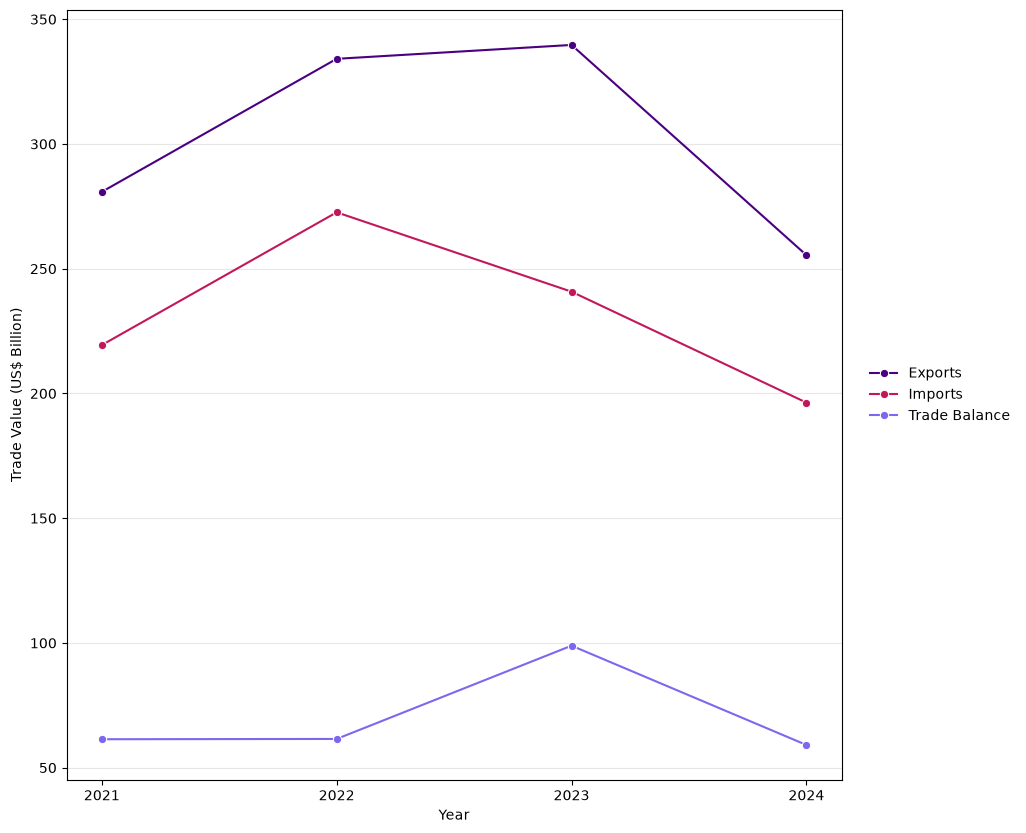

In [145]:

cores = {
        'Exports': '#4B0082',
        'Imports': '#C2185B',
        'Trade Balance': '#7B68EE'
        }
plt.figure(figsize=(10,10))
sns.lineplot(x='year', 
            y='total_value_billion_usd', 
            data = grafico_long, 
            hue = 'type_operation',
            palette =cores,
            marker= 'o'
            )
#plt.title('Brazilian Exports, Imports and Trade Balance (2021–2024)')
plt.ylabel('Trade Value (US$ Billion)')
plt.xlabel('Year')
plt.xticks([2021, 2022, 2023, 2024])
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.grid(axis="y", alpha=0.3)
plt.show()


Between 2021 and 2022, exports increased by nearly 19%, but imports grew even faster (24%), resulting in an almost unchanged trade balance. In 2023, the trade surplus increased by over 60%, mainly because imports declined by 11.7%, while exports remained relatively stable. Therefore, the improvement in Brazil's trade balance in 2023 was driven primarily by lower imports rather than stronger export growth.

### What factors contributed to the slowdown in Brazilian export growth between 2022 and 2023?

In [72]:
query = """
SELECT 
year,
month,
type_operation,
SUM(value_usd) as total_value_usd,
country_name_en,
bec_level_1_description_en
FROM `foreign-trade-brazil.analytics.mart_foreign_trade`
WHERE year BETWEEN 2021 AND 2023
GROUP BY year, 
month,
type_operation,
bec_level_1_description_en,
country_name_en
ORDER BY
year,
month,
type_operation
"""

q2 = client.query(query).to_dataframe()

print(q2.columns.tolist())

c:\Users\gabii\anaconda3\envs\foreign-trade-brazil\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


['year', 'month', 'type_operation', 'total_value_usd', 'country_name_en', 'bec_level_1_description_en']


In [73]:
q2.head()

,year,month,type_operation,total_value_usd,country_name_en,bec_level_1_description_en
0,2021,1,Exportação,129738,Comoros,FUELS AND LUBRICANTS
1,2021,1,Exportação,651895,Cayman Islands,FUELS AND LUBRICANTS
2,2021,1,Exportação,1795210,Palestine,CONSUMER GOODS (BC)
3,2021,1,Exportação,3269116,Somalia,CONSUMER GOODS (BC)
4,2021,1,Exportação,1072005,Cambodia,INTERMEDIATE GOODS (BI)


In [74]:
country_value = (
    q2.groupby(['country_name_en', 'type_operation', 'year'], as_index=False)['total_value_usd']
      .sum()
)

In [75]:
top15 = (
    country_value.groupby('country_name_en')['total_value_usd']
    .sum()
    .nlargest(15)
    .index
)

country_value_top15 = country_value[
    country_value['country_name_en'].isin(top15)
]

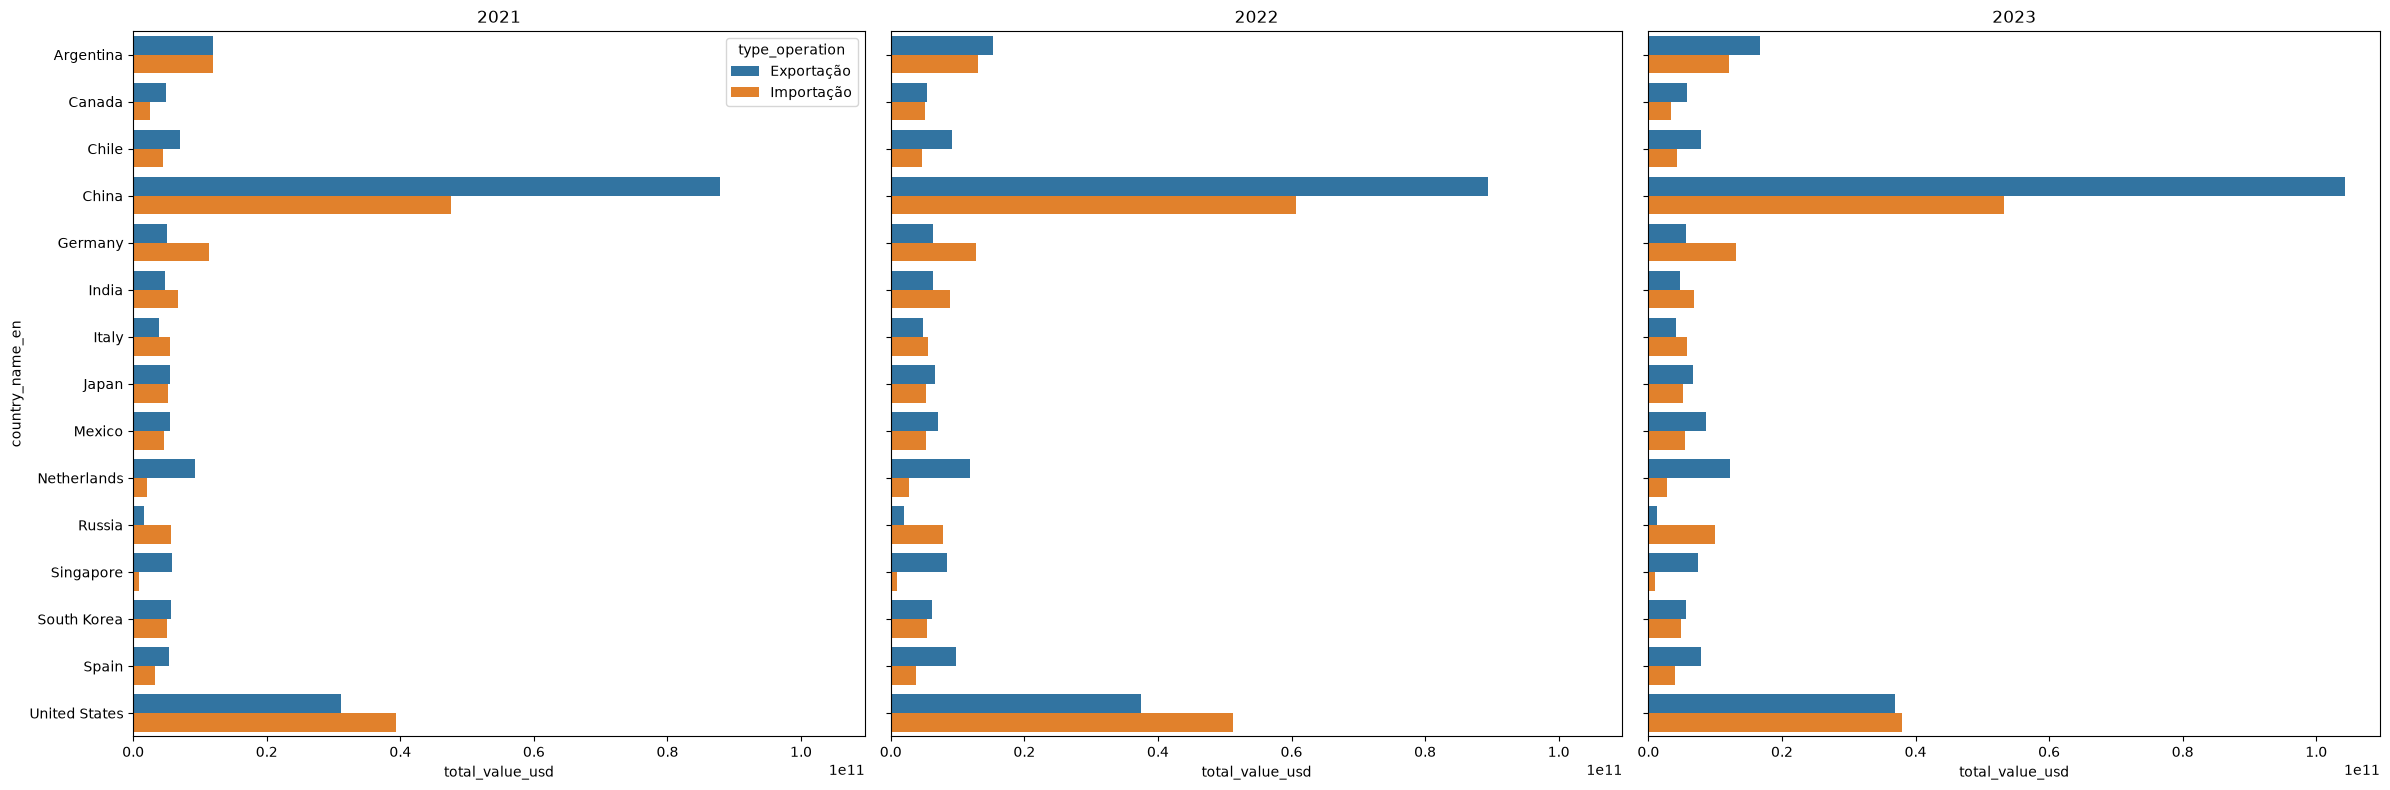

In [76]:
fig, ax = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)

# 2021
sns.barplot(
    data=country_value_top15.query("year == 2021"),
    y="country_name_en",
    x="total_value_usd",
    hue="type_operation",
    ax=ax[0]
)

# 2022
sns.barplot(
    data=country_value_top15.query("year == 2022"),
    y="country_name_en",
    x="total_value_usd",
    hue="type_operation",
    ax=ax[1]
)

# 2023
sns.barplot(
    data=country_value_top15.query("year == 2023"),
    y="country_name_en",
    x="total_value_usd",
    hue="type_operation",
    ax=ax[2]
)

ax[0].set_title("2021")
ax[1].set_title("2022")
ax[2].set_title("2023")

# Remove as legendas repetidas
ax[1].legend_.remove()
ax[2].legend_.remove()

plt.tight_layout()
plt.show()

In [77]:
country_share = (
    q2.groupby(['country_name_en', 'year', 'type_operation'])['total_value_usd']
      .sum()
      .reset_index()
)

country_share['share'] = (
    country_share['total_value_usd'] /
    country_share['total_value_usd'].sum() * 100
).round(2)

country_share.sort_values('share', ascending=False)

,country_name_en,year,type_operation,total_value_usd,share
273,China,2023,Exportação,104324811805,6.18
271,China,2022,Exportação,89427761284,5.3
269,China,2021,Exportação,87907887856,5.21
272,China,2022,Importação,60743964876,3.6
274,China,2023,Importação,53175757148,3.15
...,...,...,...,...,...
12,Aland Islands,2022,Importação,1224682,0.0
11,Aland Islands,2022,Exportação,2368,0.0
10,Aland Islands,2021,Importação,100466,0.0
9,Aland Islands,2021,Exportação,132,0.0


In [78]:
country_share = country_share[country_share['type_operation']== "Exportação"]

In [79]:
country_share = country_share.sort_values(
    by='total_value_usd',
    ascending=False
)

country_share.head(15)

,country_name_en,year,type_operation,total_value_usd,share
273,China,2023,Exportação,104324811805,6.18
271,China,2022,Exportação,89427761284,5.3
269,China,2021,Exportação,87907887856,5.21
1360,United States,2022,Exportação,37437814354,2.22
1362,United States,2023,Exportação,36915459733,2.19
1358,United States,2021,Exportação,31145209269,1.85
65,Argentina,2023,Exportação,16712209284,0.99
63,Argentina,2022,Exportação,15344651930,0.91
905,Netherlands,2023,Exportação,12148381795,0.72
903,Netherlands,2022,Exportação,11927910064,0.71


In [80]:
country_share.describe()

,year,total_value_usd,share
count,728.0,728.0,728.0
mean,2022.004121,1311327447.373626,0.077294
std,0.815081,6641513420.940306,0.393686
min,2021.0,38.0,0.0
25%,2021.0,3331599.5,0.0
50%,2022.0,43202086.5,0.0
75%,2023.0,410675074.0,0.02
max,2023.0,104324811805.0,6.18


In [81]:
export = (
    country_share[country_share['type_operation'] == 'Exportação']
    .pivot(
        index='country_name_en',
        columns='year',
        values='total_value_usd'
    )
)

export.head()

year,2021,2022,2023
country_name_en,,,
\r\nHeard Island and McDonald Islands,<NA>,303714,1119497
Afghanistan,15834475,2751417,4025760
Aland Islands,132,2368,31892
Albania,59496349,90501023,100489235
Algeria,1518387137,1917776167,2373913302


In [82]:
export['2022_vs_2021 (%)'] = (
    (export[2022] - export[2021]) / export[2021] * 100
).round(2)

export['2023_vs_2022 (%)'] = (
    (export[2023] - export[2022]) / export[2022] * 100
).round(2)

In [83]:
export.sort_values(by='2023_vs_2022 (%)', ascending = False)

year,2021,2022,2023,2022_vs_2021 (%),2023_vs_2022 (%)
country_name_en,,,,,
Greenland,<NA>,39,52867,<NA>,135456.41
British Indian Ocean Territory,<NA>,175,118976,<NA>,67886.29
Saint Helena,<NA>,9854,905224,<NA>,9086.36
Burundi,252073,6483,304909,-97.43,4603.21
Tajikistan,95362,86539,2277225,-9.25,2531.44
...,...,...,...,...,...
North Korea,<NA>,<NA>,98191,<NA>,<NA>
Northern Marianas,68192,180,<NA>,-99.74,<NA>
Saint Pierre and Miquelon,259939,<NA>,<NA>,<NA>,<NA>


In [84]:
top15 = (
    export[2023]
    .sort_values(ascending=False)
    .head(15)
    .index
)

export_top15 = export.loc[top15]

In [85]:
export_top15.sort_values(
    by='2023_vs_2022 (%)',
    ascending=False
)

year,2021,2022,2023,2022_vs_2021 (%),2023_vs_2022 (%)
country_name_en,,,,,
Indonesia,2044218977,3095480738,4110204815,51.43,32.78
Mexico,5560486888,7050909571,8571678431,26.8,21.57
China,87907887856,89427761284,104324811805,1.73,16.66
Argentina,11878463042,15344651930,16712209284,29.18,8.91
Canada,4922330196,5396844717,5772279323,9.64,6.96
Netherlands,9316019600,11927910064,12148381795,28.04,1.85
Japan,5539499830,6619791049,6620217025,19.5,0.01
United States,31145209269,37437814354,36915459733,20.2,-1.4
South Korea,5670844906,6205931665,5640635083,9.44,-9.11


In [86]:
print(export_top15.columns)

Index([2021, 2022, 2023, '2022_vs_2021 (%)', '2023_vs_2022 (%)'], dtype='object', name='year')


In [87]:
export_top15['abs_diff_2023_vs_2022'] = export_top15[2023] - export_top15[2022]  
export_top15['abs_diff_2022_vs_2021'] = export_top15[2022] - export_top15[2021]  


In [88]:
export_top15

year,2021,2022,2023,2022_vs_2021 (%),2023_vs_2022 (%),abs_diff_2023_vs_2022,abs_diff_2022_vs_2021
country_name_en,,,,,,,
China,87907887856,89427761284,104324811805,1.73,16.66,14897050521,1519873428
United States,31145209269,37437814354,36915459733,20.2,-1.4,-522354621,6292605085
Argentina,11878463042,15344651930,16712209284,29.18,8.91,1367557354,3466188888
Netherlands,9316019600,11927910064,12148381795,28.04,1.85,220471731,2611890464
Mexico,5560486888,7050909571,8571678431,26.8,21.57,1520768860,1490422683
Chile,7018693189,9094253694,7944784712,29.57,-12.64,-1149468982,2075560505
Spain,5433174458,9747538076,7858769806,79.41,-19.38,-1888768270,4314363618
Singapore,5820713782,8396198951,7459246165,44.25,-11.16,-936952786,2575485169
Japan,5539499830,6619791049,6620217025,19.5,0.01,425976,1080291219


In [89]:
export_top15.sort_values(
    by='2023_vs_2022 (%)'
)

year,2021,2022,2023,2022_vs_2021 (%),2023_vs_2022 (%),abs_diff_2023_vs_2022,abs_diff_2022_vs_2021
country_name_en,,,,,,,
India,4799018415,6301513662,4686024342,31.31,-25.64,-1615489320,1502495247
Spain,5433174458,9747538076,7858769806,79.41,-19.38,-1888768270,4314363618
Italy,3861445326,4891739114,4085106804,26.68,-16.49,-806632310,1030293788
Chile,7018693189,9094253694,7944784712,29.57,-12.64,-1149468982,2075560505
Singapore,5820713782,8396198951,7459246165,44.25,-11.16,-936952786,2575485169
Germany,5042729163,6269326305,5646806466,24.32,-9.93,-622519839,1226597142
South Korea,5670844906,6205931665,5640635083,9.44,-9.11,-565296582,535086759
United States,31145209269,37437814354,36915459733,20.2,-1.4,-522354621,6292605085
Japan,5539499830,6619791049,6620217025,19.5,0.01,425976,1080291219


In [90]:
export_top15.sort_values(
    by='abs_diff_2023_vs_2022'
)

year,2021,2022,2023,2022_vs_2021 (%),2023_vs_2022 (%),abs_diff_2023_vs_2022,abs_diff_2022_vs_2021
country_name_en,,,,,,,
Spain,5433174458,9747538076,7858769806,79.41,-19.38,-1888768270,4314363618
India,4799018415,6301513662,4686024342,31.31,-25.64,-1615489320,1502495247
Chile,7018693189,9094253694,7944784712,29.57,-12.64,-1149468982,2075560505
Singapore,5820713782,8396198951,7459246165,44.25,-11.16,-936952786,2575485169
Italy,3861445326,4891739114,4085106804,26.68,-16.49,-806632310,1030293788
Germany,5042729163,6269326305,5646806466,24.32,-9.93,-622519839,1226597142
South Korea,5670844906,6205931665,5640635083,9.44,-9.11,-565296582,535086759
United States,31145209269,37437814354,36915459733,20.2,-1.4,-522354621,6292605085
Japan,5539499830,6619791049,6620217025,19.5,0.01,425976,1080291219


In [91]:
summary01 = (
    export_top15[
        [2022,
         2023,
         '2023_vs_2022 (%)',
         'abs_diff_2023_vs_2022']
    ]
    .rename(columns={
        2022: 'Export_2022_USD',
        2023: 'Export_2023_USD',
        '2023_vs_2022 (%)': 'Growth_2023_vs_2022 (%)',
        'abs_diff_2023_vs_2022': 'Difference_USD'
    })
)

summary01

year,Export_2022_USD,Export_2023_USD,Growth_2023_vs_2022 (%),Difference_USD
country_name_en,,,,
China,89427761284,104324811805,16.66,14897050521
United States,37437814354,36915459733,-1.4,-522354621
Argentina,15344651930,16712209284,8.91,1367557354
Netherlands,11927910064,12148381795,1.85,220471731
Mexico,7050909571,8571678431,21.57,1520768860
Chile,9094253694,7944784712,-12.64,-1149468982
Spain,9747538076,7858769806,-19.38,-1888768270
Singapore,8396198951,7459246165,-11.16,-936952786
Japan,6619791049,6620217025,0.01,425976


In [92]:
summary = summary01.sort_values(
    by='Difference_USD',
    ascending=True
)

summary

year,Export_2022_USD,Export_2023_USD,Growth_2023_vs_2022 (%),Difference_USD
country_name_en,,,,
Spain,9747538076,7858769806,-19.38,-1888768270
India,6301513662,4686024342,-25.64,-1615489320
Chile,9094253694,7944784712,-12.64,-1149468982
Singapore,8396198951,7459246165,-11.16,-936952786
Italy,4891739114,4085106804,-16.49,-806632310
Germany,6269326305,5646806466,-9.93,-622519839
South Korea,6205931665,5640635083,-9.11,-565296582
United States,37437814354,36915459733,-1.4,-522354621
Japan,6619791049,6620217025,0.01,425976


In [93]:
summary_display02 = summary01.copy()

summary_display02['Export_2022_USD'] = (
    summary_display02['Export_2022_USD'] / 1e6
).round(1)

summary_display02['Export_2023_USD'] = (
    summary_display02['Export_2023_USD'] / 1e6
).round(1)

summary_display02['Difference_USD'] = (
    summary_display02['Difference_USD'] / 1e6
).round(1)

summary_display02

year,Export_2022_USD,Export_2023_USD,Growth_2023_vs_2022 (%),Difference_USD
country_name_en,,,,
China,89427.8,104324.8,16.66,14897.1
United States,37437.8,36915.5,-1.4,-522.4
Argentina,15344.7,16712.2,8.91,1367.6
Netherlands,11927.9,12148.4,1.85,220.5
Mexico,7050.9,8571.7,21.57,1520.8
Chile,9094.3,7944.8,-12.64,-1149.5
Spain,9747.5,7858.8,-19.38,-1888.8
Singapore,8396.2,7459.2,-11.16,-937.0
Japan,6619.8,6620.2,0.01,0.4


In [94]:
summary_display02.sort_values(
    by='Difference_USD'
)

year,Export_2022_USD,Export_2023_USD,Growth_2023_vs_2022 (%),Difference_USD
country_name_en,,,,
Spain,9747.5,7858.8,-19.38,-1888.8
India,6301.5,4686.0,-25.64,-1615.5
Chile,9094.3,7944.8,-12.64,-1149.5
Singapore,8396.2,7459.2,-11.16,-937.0
Italy,4891.7,4085.1,-16.49,-806.6
Germany,6269.3,5646.8,-9.93,-622.5
South Korea,6205.9,5640.6,-9.11,-565.3
United States,37437.8,36915.5,-1.4,-522.4
Japan,6619.8,6620.2,0.01,0.4


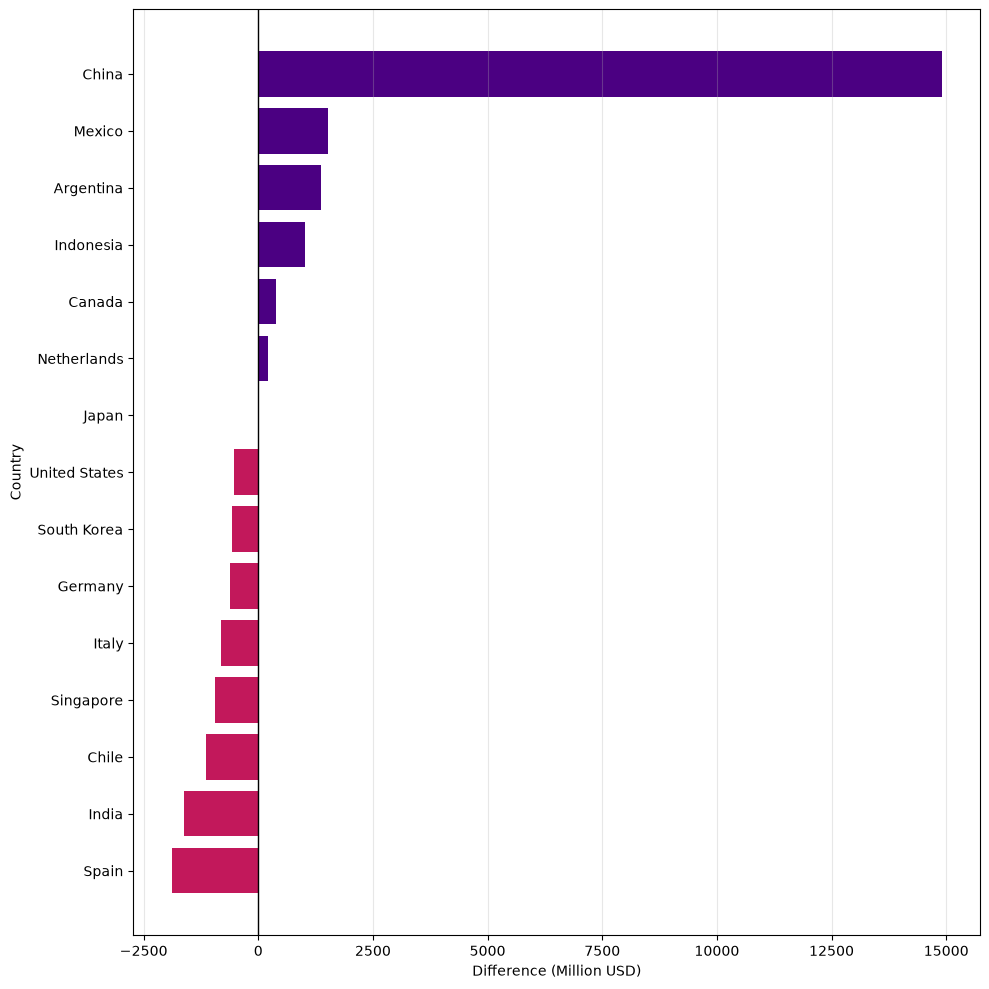

In [146]:
import matplotlib.pyplot as plt

df = summary_display02.sort_values('Difference_USD')

cores = [
    '#C2185B' if x < 0 else '#4B0082'
    for x in df['Difference_USD']
]

plt.figure(figsize=(10,10))

plt.barh(
    df.index,
    df['Difference_USD'],
    color=cores
)

plt.axvline(0, color='black', linewidth=1)

#plt.title('Difference in Brazilian Exports (2023 vs 2022)')
plt.xlabel('Difference (Million USD)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=.3)

plt.tight_layout()
plt.show()

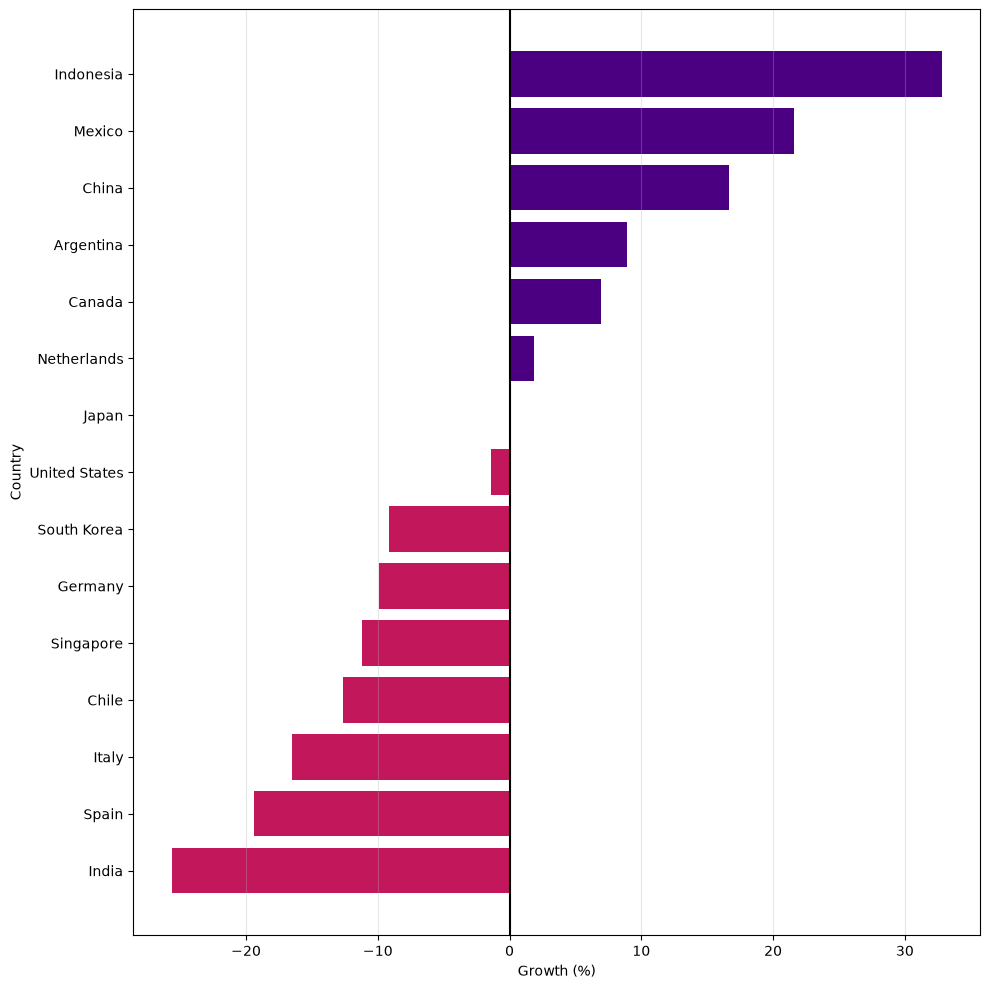

In [148]:
df = summary_display02.sort_values('Growth_2023_vs_2022 (%)')

cores = [
    '#C2185B' if x < 0 else '#4B0082'
    for x in df['Growth_2023_vs_2022 (%)']
]

plt.figure(figsize=(10,10))

plt.barh(
    df.index,
    df['Growth_2023_vs_2022 (%)'],
    color=cores
)

plt.axvline(0, color='black')

#plt.title('Growth Rate (2023 vs 2022)')
plt.xlabel('Growth (%)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=.3)

plt.tight_layout()
plt.show()

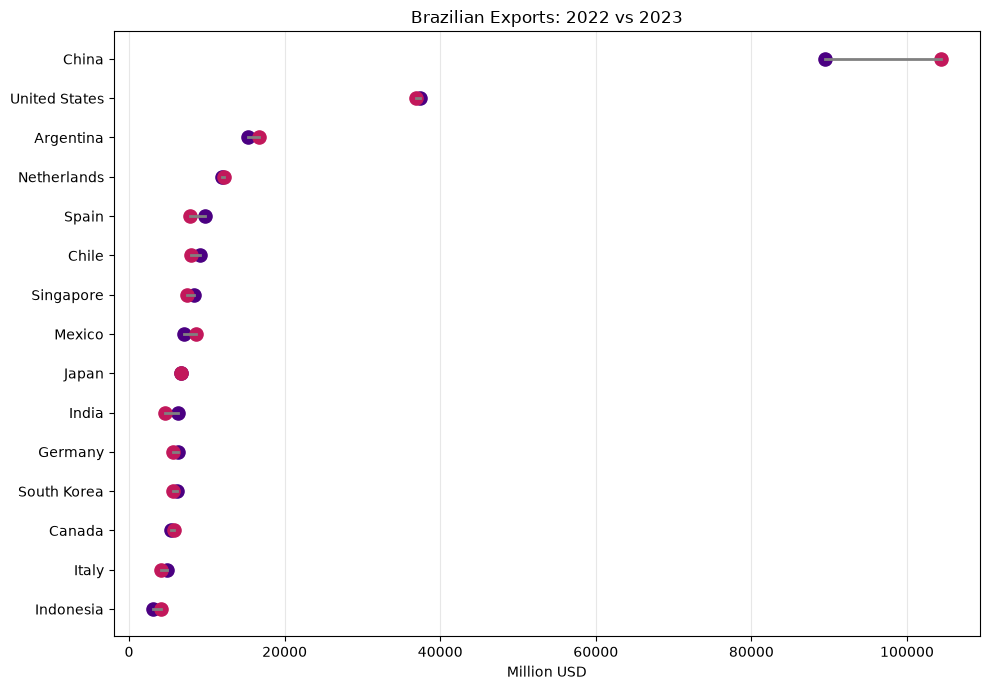

In [97]:
fig, ax = plt.subplots(figsize=(10,7))

df = summary_display02.sort_values('Export_2022_USD')

for i, (pais, row) in enumerate(df.iterrows()):

    ax.plot(
        [row['Export_2022_USD'], row['Export_2023_USD']],
        [i, i],
        color='gray',
        linewidth=2
    )

    ax.scatter(
        row['Export_2022_USD'],
        i,
        s=90,
        color='#4B0082'
    )

    ax.scatter(
        row['Export_2023_USD'],
        i,
        s=90,
        color='#C2185B'
    )

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index)

ax.set_xlabel('Million USD')
ax.set_title('Brazilian Exports: 2022 vs 2023')

plt.grid(axis='x', alpha=.3)

plt.tight_layout()

plt.show()

Although the total value of Brazilian exports remained high in 2023, several trading partners saw a decline in purchases compared to 2022. Spain, India, and Chile recorded the largest absolute losses, with decreases of approximately US$ 188.9 million, US$ 161.5 million, and US$ 114.9 million, respectively. In relative terms, India saw the largest decline among the major trading partners (-25.6%), followed by Spain (-19.4%) and Italy (-16.5%). These results indicate that the slowdown in exports in 2023 was driven primarily by a decline in sales to key markets, while only a few trading partners—such as China, Mexico, and Indonesia—maintained significant growth.

In [98]:
growth_summary = pd.DataFrame({
    'Period': ['2022 vs 2021', '2023 vs 2022'],
    'Median Growth (%)': [
        export_top15['2022_vs_2021 (%)'].median().round(2),
        export_top15['2023_vs_2022 (%)'].median().round(2)
    ]
})

growth_summary

,Period,Median Growth (%)
0,2022 vs 2021,26.8
1,2023 vs 2022,-1.4


In [99]:
summary = pd.DataFrame({
    'Period': ['2022 vs 2021', '2023 vs 2022'],
    'Countries with growth': [
        (export['2022_vs_2021 (%)'] > 0).sum(),
        (export['2023_vs_2022 (%)'] > 0).sum()
    ],
    'Countries with decline': [
        (export['2022_vs_2021 (%)'] < 0).sum(),
        (export['2023_vs_2022 (%)'] < 0).sum()
    ]
})

summary

,Period,Countries with growth,Countries with decline
0,2022 vs 2021,182,56
1,2023 vs 2022,127,114


The data indicate a slowdown in the growth of Brazilian exports between 2022 and 2023. While virtually all major destinations recorded significant growth between 2021 and 2022, the pace of expansion slowed considerably between 2022 and 2023, and several trading partners began to see a decline in imports of Brazilian products. China remained one of the main drivers of growth, recording a 16.66% increase in Brazilian exports, but this growth was not matched by most other markets.

Was the slowdown in export growth between 2022 and 2023 driven by lower export volumes, lower average prices, or both?

Analysis 4.1

Export volume (kg) by country.

Analysis 4.2

Average export price (USD/kg) by country.

Analysis 4.3

Compare volume and price changes to identify the main driver.

In [100]:
query = """
SELECT 
year,
type_operation,
SUM(value_usd) as total_value_usd,
country_name_en,
bec_level_1_description_en,
SUM(net_weight_kg) as total_net_weight
FROM `foreign-trade-brazil.analytics.mart_foreign_trade`
WHERE year BETWEEN 2021 AND 2023
GROUP BY year, 
type_operation,
bec_level_1_description_en,
country_name_en,
net_weight_kg
ORDER BY
year,
type_operation
"""

q3 = client.query(query).to_dataframe()

print(q3.columns.tolist())

c:\Users\gabii\anaconda3\envs\foreign-trade-brazil\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


['year', 'type_operation', 'total_value_usd', 'country_name_en', 'bec_level_1_description_en', 'total_net_weight']


In [101]:
q3[q3['type_operation']=="Exportação"]

,year,type_operation,total_value_usd,country_name_en,bec_level_1_description_en,total_net_weight
0,2021,Exportação,19537,Malta,CONSUMER GOODS (BC),10920
1,2021,Exportação,309418,Bolivia,INTERMEDIATE GOODS (BI),2125
2,2021,Exportação,8513,Bolivia,INTERMEDIATE GOODS (BI),2061
3,2021,Exportação,277054,Bolivia,CAPITAL GOODS (BK),31230
4,2021,Exportação,866155,France,CAPITAL GOODS (BK),0
...,...,...,...,...,...,...
2088448,2023,Exportação,332038,Paraguay,INTERMEDIATE GOODS (BI),25059
2088449,2023,Exportação,155608,Argentina,CAPITAL GOODS (BK),3439
2088450,2023,Exportação,46003,Chile,CONSUMER GOODS (BC),23227
2088451,2023,Exportação,184372,Chile,INTERMEDIATE GOODS (BI),42540


In [102]:
q3["country_name_en"].unique()

<ArrowStringArray>
[                                'Malta',
                               'Bolivia',
                                'France',
                                 'Japan',
                                'Turkey',
                          'Saudi Arabia',
                               'Liberia',
                      'Marshall Islands',
                               'Germany',
                                 'China',
 ...
                           'North Korea',
                          'Saint Helena',
                          'Vatican City',
           'International Organizations',
 '\r\nHeard Island and McDonald Islands',
                        'Western Sahara',
                             'Greenland',
        'British Indian Ocean Territory',
                         'Central Banks',
                'Svalbard and Jan Mayen']
Length: 251, dtype: str

In [103]:
export_df = q3[q3['type_operation'] == 'Exportação'].copy()

In [104]:
export_df['type_operation'].value_counts()

type_operation
Exportação    1229728
Name: count, dtype: int64

In [105]:
export_df['country_name_en'].unique()

<ArrowStringArray>
[                                       'Malta',
                                      'Bolivia',
                                       'France',
                                        'Japan',
                                       'Turkey',
                                 'Saudi Arabia',
                                      'Liberia',
                             'Marshall Islands',
                                      'Germany',
                                        'China',
 ...
                                      'Tokelau',
        '\r\nHeard Island and McDonald Islands',
                                 'Vatican City',
 'South Georgia and the South Sandwich Islands',
                                 'Saint Helena',
                               'Western Sahara',
                                    'Greenland',
               'British Indian Ocean Territory',
                                  'North Korea',
                       'Svalbard and Jan Maye

In [106]:
df03 = export_df.groupby(['year', 'country_name_en', 'bec_level_1_description_en'])[['total_value_usd', 'total_net_weight']].sum().reset_index()

In [107]:
countries = [
    'China', 'United States', 'Argentina', 'Netherlands',
    'Mexico', 'Chile', 'Spain', 'Singapore', 'Japan', 'Canada',
    'Germany', 'South Corea', 'India', 'Indonesia', 'Italy'
]

df03_top = df03[df03['country_name_en'].isin(countries)]

In [108]:
df03_top.head()

,year,country_name_en,bec_level_1_description_en,total_value_usd,total_net_weight
27,2021,Argentina,CAPITAL GOODS (BK),1236951257,139325095
28,2021,Argentina,CONSUMER GOODS (BC),2229709337,464258560
29,2021,Argentina,FUELS AND LUBRICANTS,73457254,34971888
30,2021,Argentina,INTERMEDIATE GOODS (BI),8338345194,8619385943
127,2021,Canada,CAPITAL GOODS (BK),171143314,19387278


In [109]:
df03_top.sort_values(by='total_value_usd', ascending = False)

,year,country_name_en,bec_level_1_description_en,total_value_usd,total_net_weight
1798,2023,China,INTERMEDIATE GOODS (BI),76379337588,373366233749
153,2021,China,INTERMEDIATE GOODS (BI),67615821238,323458870988
971,2022,China,INTERMEDIATE GOODS (BI),63025416815,311783630494
1604,2022,United States,INTERMEDIATE GOODS (BI),23288497080,23458869890
2451,2023,United States,INTERMEDIATE GOODS (BI),21449569950,24048419945
...,...,...,...,...,...
770,2021,United States,GOODS NOT SPECIFIED PREVIOUSLY,26270,3009
341,2021,Indonesia,FUELS AND LUBRICANTS,15389,7560
1797,2023,China,GOODS NOT SPECIFIED PREVIOUSLY,6586,3430
1995,2023,India,GOODS NOT SPECIFIED PREVIOUSLY,19,1


In [110]:
df03_top['country_name_en'].unique()

<ArrowStringArray>
[    'Argentina',        'Canada',         'Chile',         'China',
       'Germany',         'India',     'Indonesia',         'Italy',
         'Japan',        'Mexico',   'Netherlands',     'Singapore',
         'Spain', 'United States']
Length: 14, dtype: str

In [111]:
pivot = (
    df03_top.pivot_table(
        index=['country_name_en', 'bec_level_1_description_en'],
        columns='year',
        values=['total_value_usd', 'total_net_weight']
    )
)

In [112]:
pivot.head()

total_net_weight                \
year                                                   2021          2022   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)              139325095.0   151579907.0   
                CONSUMER GOODS (BC)             464258560.0   462931888.0   
                FUELS AND LUBRICANTS             34971888.0   362293191.0   
                INTERMEDIATE GOODS (BI)        8619385943.0  8282305660.0   
Canada          CAPITAL GOODS (BK)               19387278.0    21358118.0   

                                                          total_value_usd  \
year                                                 2023            2021   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)            115512384.0    1236951257.0   
                CONSUMER GOODS (BC)           360111043.0    2229709337.0   
                FUELS AND LUBRICANTS          363701568.0      73457254.0   
                INTERMEDIATE GOODS (BI)     11758221290.0    8338345194.0   
Canada          CAPITAL GOODS (BK)             29777095.0     171143314.0   

                                                                          
year                                                 2022           2023  
country_name_en bec_level_1_description_en                                
Argentina       CAPITAL GOODS (BK)           1639239534.0   1395635288.0  
                CONSUMER GOODS (BC)          2624492912.0   2535790098.0  
                FUELS AND LUBRICANTS          702978817.0    719006010.0  
                INTERMEDIATE GOODS (BI)     10377940667.0  12061777888.0  
Canada          CAPITAL GOODS (BK)            315392909.0   1001174212.0

In [113]:
pivot['price_2021'] = pivot[('total_value_usd', 2021)] / pivot[('total_net_weight', 2021)]
pivot['price_2022'] = pivot[('total_value_usd', 2022)] / pivot[('total_net_weight', 2022)]
pivot['price_2023'] = pivot[('total_value_usd', 2023)] / pivot[('total_net_weight', 2023)]

In [114]:
pivot.head()

total_net_weight                \
year                                                   2021          2022   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)              139325095.0   151579907.0   
                CONSUMER GOODS (BC)             464258560.0   462931888.0   
                FUELS AND LUBRICANTS             34971888.0   362293191.0   
                INTERMEDIATE GOODS (BI)        8619385943.0  8282305660.0   
Canada          CAPITAL GOODS (BK)               19387278.0    21358118.0   

                                                          total_value_usd  \
year                                                 2023            2021   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)            115512384.0    1236951257.0   
                CONSUMER GOODS (BC)           360111043.0    2229709337.0   
                FUELS AND LUBRICANTS          363701568.0      73457254.0   
                INTERMEDIATE GOODS (BI)     11758221290.0    8338345194.0   
Canada          CAPITAL GOODS (BK)             29777095.0     171143314.0   

                                                                          \
year                                                 2022           2023   
country_name_en bec_level_1_description_en                                 
Argentina       CAPITAL GOODS (BK)           1639239534.0   1395635288.0   
                CONSUMER GOODS (BC)          2624492912.0   2535790098.0   
                FUELS AND LUBRICANTS          702978817.0    719006010.0   
                INTERMEDIATE GOODS (BI)     10377940667.0  12061777888.0   
Canada          CAPITAL GOODS (BK)            315392909.0   1001174212.0   

                                           price_2021 price_2022 price_2023  
year                                                                         
country_name_en bec_level_1_description_en                                   
Argentina       CAPITAL GOODS (BK)           8.878166  10.814359  12.082127  
                CONSUMER GOODS (BC)          4.802732   5.669285   7.041689  
                FUELS AND LUBRICANTS         2.100466   1.940359   1.976912  
                INTERMEDIATE GOODS (BI)      0.967394   1.253026   1.025817  
Canada          CAPITAL GOODS (BK)           8.827609  14.766887  33.622293

In [115]:
pivot['weight_2022_vs_2021 (%)'] = (
    (pivot[('total_net_weight', 2022)] - pivot[('total_net_weight', 2021)])
    / pivot[('total_net_weight', 2021)] * 100
).round(2)

pivot['weight_2023_vs_2022 (%)'] = (
    (pivot[('total_net_weight', 2023)] - pivot[('total_net_weight', 2022)])
    / pivot[('total_net_weight', 2022)] * 100
).round(2)

In [116]:
pivot['price_2022_vs_2021 (%)'] = (
    (pivot['price_2022'] - pivot['price_2021'])
    / pivot['price_2021'] * 100
).round(2)

pivot['price_2023_vs_2022 (%)'] = (
    (pivot['price_2023'] - pivot['price_2022'])
    / pivot['price_2022'] * 100
).round(2)

In [117]:
pivot.head()

total_net_weight                \
year                                                   2021          2022   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)              139325095.0   151579907.0   
                CONSUMER GOODS (BC)             464258560.0   462931888.0   
                FUELS AND LUBRICANTS             34971888.0   362293191.0   
                INTERMEDIATE GOODS (BI)        8619385943.0  8282305660.0   
Canada          CAPITAL GOODS (BK)               19387278.0    21358118.0   

                                                          total_value_usd  \
year                                                 2023            2021   
country_name_en bec_level_1_description_en                                  
Argentina       CAPITAL GOODS (BK)            115512384.0    1236951257.0   
                CONSUMER GOODS (BC)           360111043.0    2229709337.0   
                FUELS AND LUBRICANTS          363701568.0      73457254.0   
                INTERMEDIATE GOODS (BI)     11758221290.0    8338345194.0   
Canada          CAPITAL GOODS (BK)             29777095.0     171143314.0   

                                                                          \
year                                                 2022           2023   
country_name_en bec_level_1_description_en                                 
Argentina       CAPITAL GOODS (BK)           1639239534.0   1395635288.0   
                CONSUMER GOODS (BC)          2624492912.0   2535790098.0   
                FUELS AND LUBRICANTS          702978817.0    719006010.0   
                INTERMEDIATE GOODS (BI)     10377940667.0  12061777888.0   
Canada          CAPITAL GOODS (BK)            315392909.0   1001174212.0   

                                           price_2021 price_2022 price_2023  \
year                                                                          
country_name_en bec_level_1_description_en                                    
Argentina       CAPITAL GOODS (BK)           8.878166  10.814359  12.082127   
                CONSUMER GOODS (BC)          4.802732   5.669285   7.041689   
                FUELS AND LUBRICANTS         2.100466   1.940359   1.976912   
                INTERMEDIATE GOODS (BI)      0.967394   1.253026   1.025817   
Canada          CAPITAL GOODS (BK)           8.827609  14.766887  33.622293   

                                           weight_2022_vs_2021 (%)  \
year                                                                 
country_name_en bec_level_1_description_en                           
Argentina       CAPITAL GOODS (BK)                             8.8   
                CONSUMER GOODS (BC)                          -0.29   
                FUELS AND LUBRICANTS                        935.96   
                INTERMEDIATE GOODS (BI)                      -3.91   
Canada          CAPITAL GOODS (BK)                           10.17   

                                           weight_2023_vs_2022 (%)  \
year                                                                 
country_name_en bec_level_1_description_en                           
Argentina       CAPITAL GOODS (BK)                          -23.79   
                CONSUMER GOODS (BC)                         -22.21   
                FUELS AND LUBRICANTS                          0.39   
                INTERMEDIATE GOODS (BI)                      41.97   
Canada          CAPITAL GOODS (BK)                           39.42   

                                           price_2022_vs_2021 (%)  \
year                                                                
country_name_en bec_level_1_description_en                          
Argentina       CAPITAL GOODS (BK)                          21.81   
                CONSUMER GOODS (BC)                         18.04   
                FUELS AND LUBRICANTS                        -7.62   
                INTERMEDIATE GO

In [118]:
pivot.columns

MultiIndex([(       'total_net_weight', 2021),
            (       'total_net_weight', 2022),
            (       'total_net_weight', 2023),
            (        'total_value_usd', 2021),
            (        'total_value_usd', 2022),
            (        'total_value_usd', 2023),
            (             'price_2021',   ''),
            (             'price_2022',   ''),
            (             'price_2023',   ''),
            ('weight_2022_vs_2021 (%)',   ''),
            ('weight_2023_vs_2022 (%)',   ''),
            ( 'price_2022_vs_2021 (%)',   ''),
            ( 'price_2023_vs_2022 (%)',   '')],
           names=[None, 'year'])

In [119]:
pivot.index

MultiIndex([(    'Argentina',             'CAPITAL GOODS (BK)'),
            (    'Argentina',            'CONSUMER GOODS (BC)'),
            (    'Argentina',           'FUELS AND LUBRICANTS'),
            (    'Argentina',        'INTERMEDIATE GOODS (BI)'),
            (       'Canada',             'CAPITAL GOODS (BK)'),
            (       'Canada',            'CONSUMER GOODS (BC)'),
            (       'Canada',           'FUELS AND LUBRICANTS'),
            (       'Canada',        'INTERMEDIATE GOODS (BI)'),
            (        'Chile',             'CAPITAL GOODS (BK)'),
            (        'Chile',            'CONSUMER GOODS (BC)'),
            (        'Chile',           'FUELS AND LUBRICANTS'),
            (        'Chile', 'GOODS NOT SPECIFIED PREVIOUSLY'),
            (        'Chile',        'INTERMEDIATE GOODS (BI)'),
            (        'China',             'CAPITAL GOODS (BK)'),
            (        'China',            'CONSUMER GOODS (BC)'),
            (        'Chi

In [120]:
sorted(pivot.index.get_level_values('country_name_en').unique())

['Argentina',
 'Canada',
 'Chile',
 'China',
 'Germany',
 'India',
 'Indonesia',
 'Italy',
 'Japan',
 'Mexico',
 'Netherlands',
 'Singapore',
 'Spain',
 'United States']

In [121]:
paises = ['Spain', 'Chile', 'India']

pivot_filtrado = pivot[
    pivot.index.get_level_values('country_name_en').isin(paises)
]

pivot_filtrado

total_net_weight  \
year                                                       2021   
country_name_en bec_level_1_description_en                        
Chile           CAPITAL GOODS (BK)                  129377058.0   
                CONSUMER GOODS (BC)                 517362794.0   
                FUELS AND LUBRICANTS               4312047690.0   
                GOODS NOT SPECIFIED PREVIOUSLY              6.0   
                INTERMEDIATE GOODS (BI)            1879504516.0   
India           CAPITAL GOODS (BK)                    3851685.0   
                CONSUMER GOODS (BC)                 136127517.0   
                FUELS AND LUBRICANTS               5105350023.0   
                GOODS NOT SPECIFIED PREVIOUSLY             <NA>   
                INTERMEDIATE GOODS (BI)            2083867643.0   
Spain           CAPITAL GOODS (BK)                    5801095.0   
                CONSUMER GOODS (BC)                 222823890.0   
                FUELS AND LUBRICANTS               2433859025.0   
                INTERMEDIATE GOODS (BI)            9755111101.0   

                                                                             \
year                                                     2022          2023   
country_name_en bec_level_1_description_en                                    
Chile           CAPITAL GOODS (BK)                140875017.0    90557451.0   
                CONSUMER GOODS (BC)               441238896.0   442594463.0   
                FUELS AND LUBRICANTS             4942400373.0  5776628488.0   
                GOODS NOT SPECIFIED PREVIOUSLY           <NA>          <NA>   
                INTERMEDIATE GOODS (BI)          1836730750.0  1782546523.0   
India           CAPITAL GOODS (BK)                  4634664.0     4881892.0   
                CONSUMER GOODS (BC)                86604811.0    82768289.0   
                FUELS AND LUBRICANTS             3245838045.0  1635023662.0   
                GOODS NOT SPECIFIED PREVIOUSLY           <NA>           1.0   
                INTERMEDIATE GOODS (BI)          3965083617.0  5665228246.0   
Spain           CAPITAL GOODS (BK)                  6666732.0     6269461.0   
                CONSUMER GOODS (BC)               181065235.0   212907689.0   
                FUELS AND LUBRICANTS             6528907107.0  6593448528.0   
                INTERMEDIATE GOODS (BI)         11694327151.0  8226093227.0   

                                               total_value_usd                \
year                                                      2021          2022   
country_name_en bec_level_1_description_en                                     
Chile           CAPITAL GOODS (BK)                1059256018.0  1383781805.0   
                CONSUMER GOODS (BC)               1620211033.0  1741469626.0   
                FUELS AND LUBRICANTS              1994819772.0  3208023886.0   
                GOODS NOT SPECIFIED PREVIOUSLY             5.0          <NA>   
                INTERMEDIATE GOODS (BI)           2344406361.0  2760978377.0   
India           CAPITAL GOODS (BK)                  41789196.0    54967895.0   
                CONSUMER GOODS (BC)                159933753.0   119003636.0   
                FUELS AND LUBRICANTS              2254653602.0  1831346705.0   
                GOODS NOT SPECIFIED PREVIOUSLY            <NA>          <NA>   
                INTERMEDIATE GOODS (BI)           2342641864.0  4296195426.0   
Spain           CAPITAL GOODS (BK)                 117312385.0    59834418.0   
                CONSUMER GOODS (BC)                266504212.0   295793425.0   
                FUELS AND LUBRICANTS              1102778444.0  3979555467.0   
                INTERMEDIATE GOODS (BI)           3946579417.0  5412354766.0   

                                                             price_2021  \
year                                                    2023              
country_name_en bec_level_1_description_en          

In [122]:
plot_df = pivot_filtrado.reset_index()

plot_df.head()

country_name_en      bec_level_1_description_en total_net_weight  \
year                                                             2021   
0              Chile              CAPITAL GOODS (BK)      129377058.0   
1              Chile             CONSUMER GOODS (BC)      517362794.0   
2              Chile            FUELS AND LUBRICANTS     4312047690.0   
3              Chile  GOODS NOT SPECIFIED PREVIOUSLY              6.0   
4              Chile         INTERMEDIATE GOODS (BI)     1879504516.0   

                                 total_value_usd                              \
year          2022          2023            2021          2022          2023   
0      140875017.0    90557451.0    1059256018.0  1383781805.0  1007299683.0   
1      441238896.0   442594463.0    1620211033.0  1741469626.0  1420117836.0   
2     4942400373.0  5776628488.0    1994819772.0  3208023886.0  3174950094.0   
3             <NA>          <NA>             5.0          <NA>          <NA>   
4     1836730750.0  1782546523.0    2344406361.0  2760978377.0  2342417099.0   

     price_2021 price_2022 price_2023 weight_2022_vs_2021 (%)  \
year                                                            
0      8.187356   9.822762  11.123322                    8.89   
1      3.131673   3.946773   3.208621                  -14.71   
2      0.462615   0.649082    0.54962                   14.62   
3      0.833333       <NA>       <NA>                    <NA>   
4      1.247353   1.503203   1.314085                   -2.28   

     weight_2023_vs_2022 (%) price_2022_vs_2021 (%) price_2023_vs_2022 (%)  
year                                                                        
0                     -35.72                  19.97                  13.24  
1                       0.31                  26.03                  -18.7  
2                      16.88                  40.31                 -15.32  
3                       <NA>                   <NA>                   <NA>  
4                      -2.95                  20.51                 -12.58

In [123]:
plot_df['bec_level_1_description_en'].unique()

<ArrowStringArray>
[            'CAPITAL GOODS (BK)',            'CONSUMER GOODS (BC)',
           'FUELS AND LUBRICANTS', 'GOODS NOT SPECIFIED PREVIOUSLY',
        'INTERMEDIATE GOODS (BI)']
Length: 5, dtype: str

In [162]:
def plot_categoria(plot_df, categoria):

    dados = plot_df[
        plot_df[('bec_level_1_description_en', '')] == categoria
    ]

    cores = {
        'Chile': '#4B0082',
        'India': '#C2185B',
        'Spain': '#7B68EE'
    }

    fig, axes = plt.subplots(1, 2, figsize=(17,12))

    for _, row in dados.iterrows():

        pais = row[('country_name_en', '')]

        # -------- Net Weight --------
        axes[0].plot(
            [2021, 2022, 2023],
            [
                row[('total_net_weight', 2021)],
                row[('total_net_weight', 2022)],
                row[('total_net_weight', 2023)]
            ],
            marker='o',
            
            color=cores[pais],
            label=pais,
            linewidth=2.5,
            markersize=7
        )

        # -------- Average Price --------
        axes[1].plot(
            [2021, 2022, 2023],
            [
                row[('price_2021', '')],
                row[('price_2022', '')],
                row[('price_2023', '')]
            ],
            marker='o',
            linewidth=2.5,
            color=cores[pais],
            label=pais
        )

    axes[0].set_title('Export Volume (kg)')
    axes[0].set_ylabel('Kg')
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Average Export Price (USD/kg)')
    axes[1].set_ylabel('USD/kg')
    axes[1].grid(alpha=0.3)

    for ax in axes:
        ax.set_xticks([2021, 2022, 2023])

    
    handles, labels = axes[0].get_legend_handles_labels()

    plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=10
)

    #fig.suptitle(categoria, fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [137]:
print(plot_df.columns)

MultiIndex([(           'country_name_en',   ''),
            ('bec_level_1_description_en',   ''),
            (          'total_net_weight', 2021),
            (          'total_net_weight', 2022),
            (          'total_net_weight', 2023),
            (           'total_value_usd', 2021),
            (           'total_value_usd', 2022),
            (           'total_value_usd', 2023),
            (                'price_2021',   ''),
            (                'price_2022',   ''),
            (                'price_2023',   ''),
            (   'weight_2022_vs_2021 (%)',   ''),
            (   'weight_2023_vs_2022 (%)',   ''),
            (    'price_2022_vs_2021 (%)',   ''),
            (    'price_2023_vs_2022 (%)',   '')],
           names=[None, 'year'])


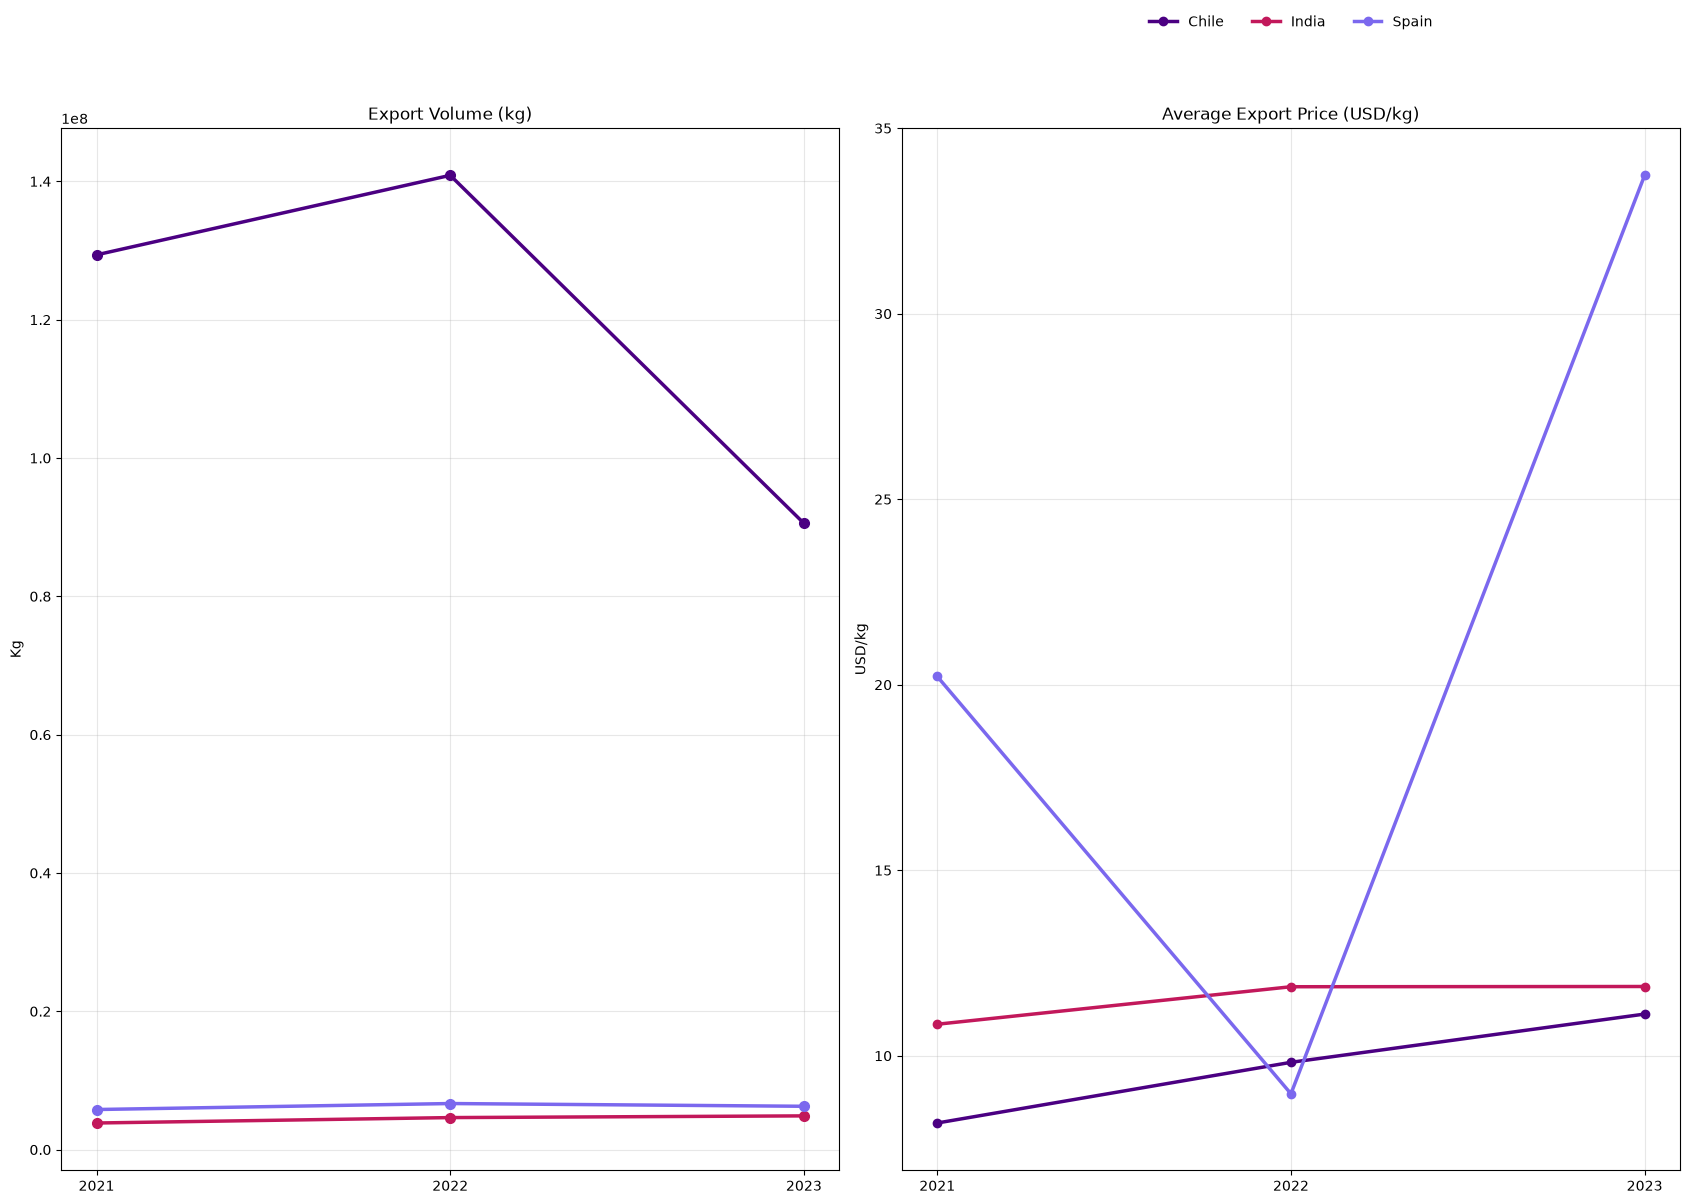

In [163]:
plot_categoria(plot_df, 'CAPITAL GOODS (BK)')

Among the three countries analyzed, Chile accounted for the largest volume of Brazilian capital goods exports during the 2021–2023 period.

In 2023, there was a 35.7% decrease in the volume exported to Chile compared to 2022. Despite this decline, the average price per kilogram continued to rise, from US$ 8.18/kg in 2021 to US$ 11.12/kg in 2023.

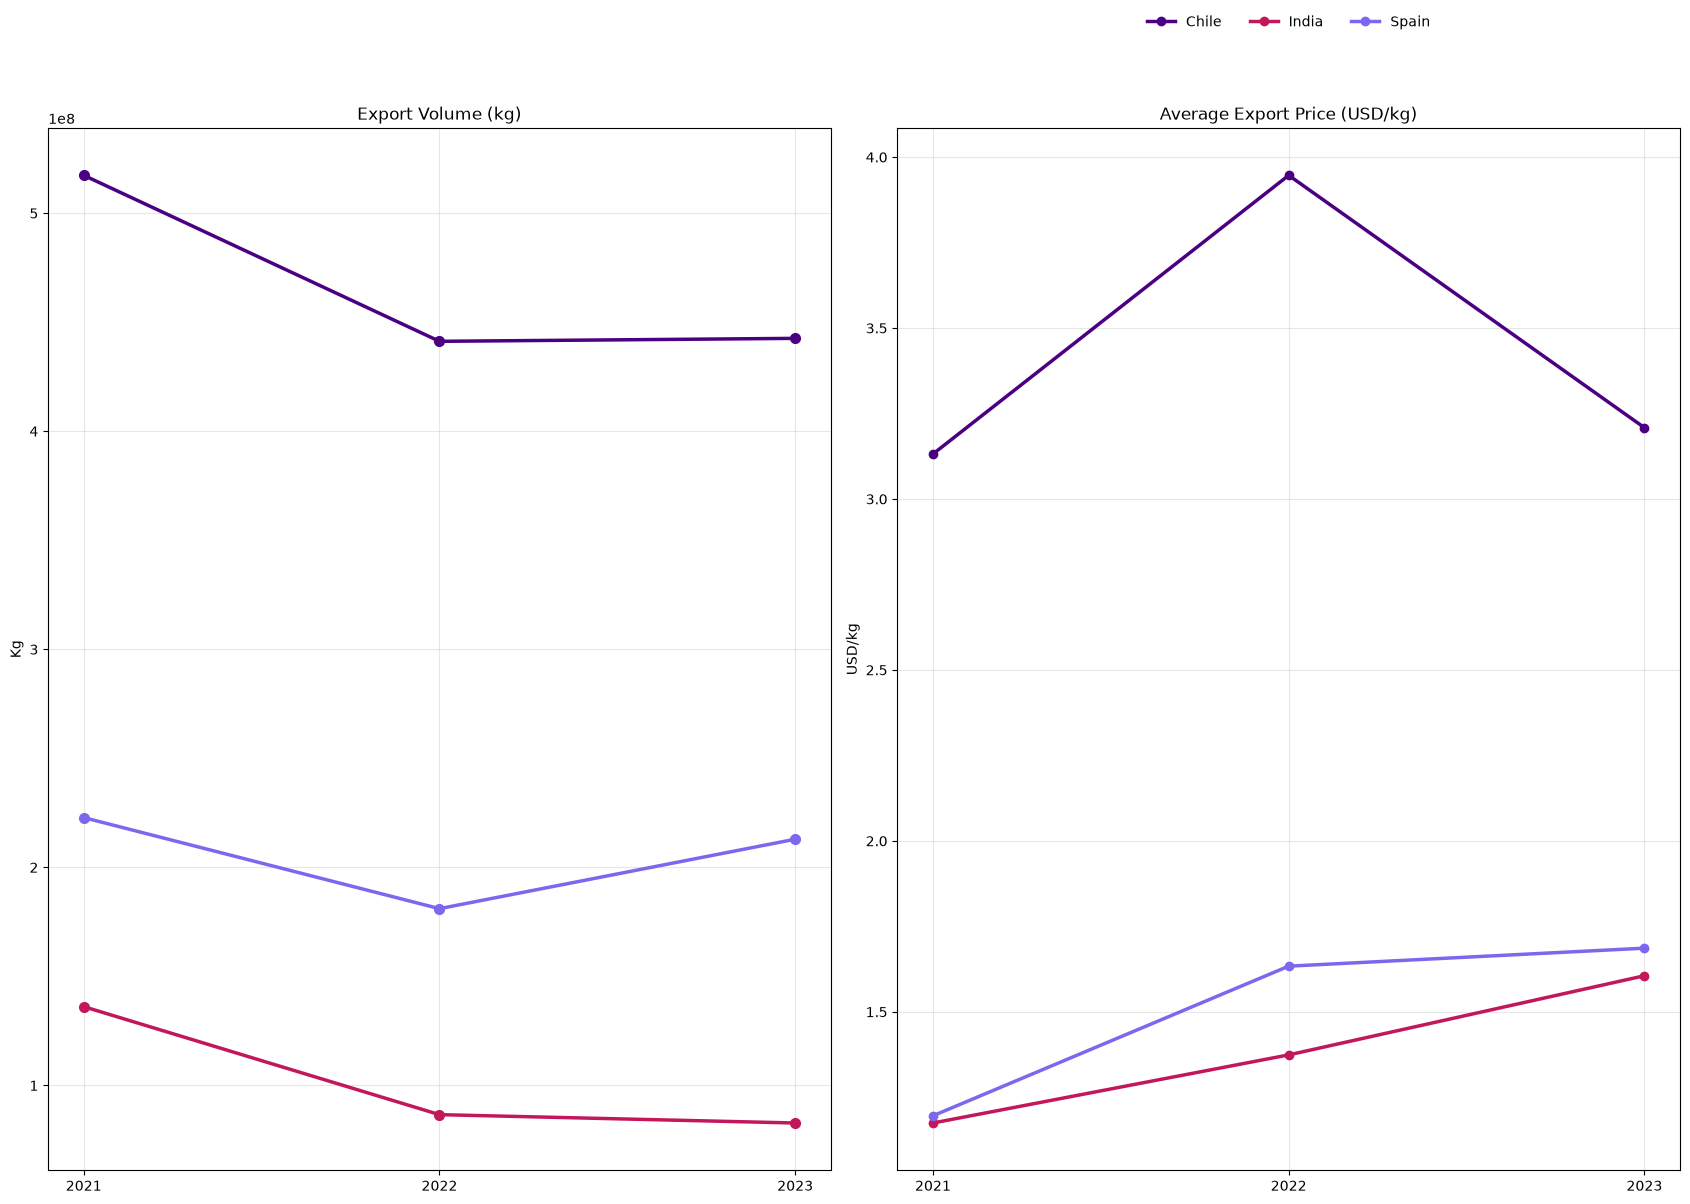

In [164]:
plot_categoria(plot_df, 'CONSUMER GOODS (BC)')

Among the three countries analyzed, Chile accounted for the largest volume of Brazilian consumer goods (CG) exports throughout the entire period. However, there was a decrease in net export weight between 2021 and 2022 (-14.7%), followed by stability between 2022 and 2023 (+0.3%). Regarding the average price per kilogram, there was an increase from US$3.13/kg to US$3.95/kg between 2021 and 2022 (+26.0%), followed by a decrease to US$3.21/kg in 2023 (-18.7%).

While Chile saw a decline in export volume, India and Spain recorded lower average prices throughout the period, though with an upward trend through 2023.

This trend suggests that, although export volume decreased compared to 2021, the Chilean market remained relatively stable in 2023, while the average price returned to a level close to that observed at the beginning of the period analyzed.

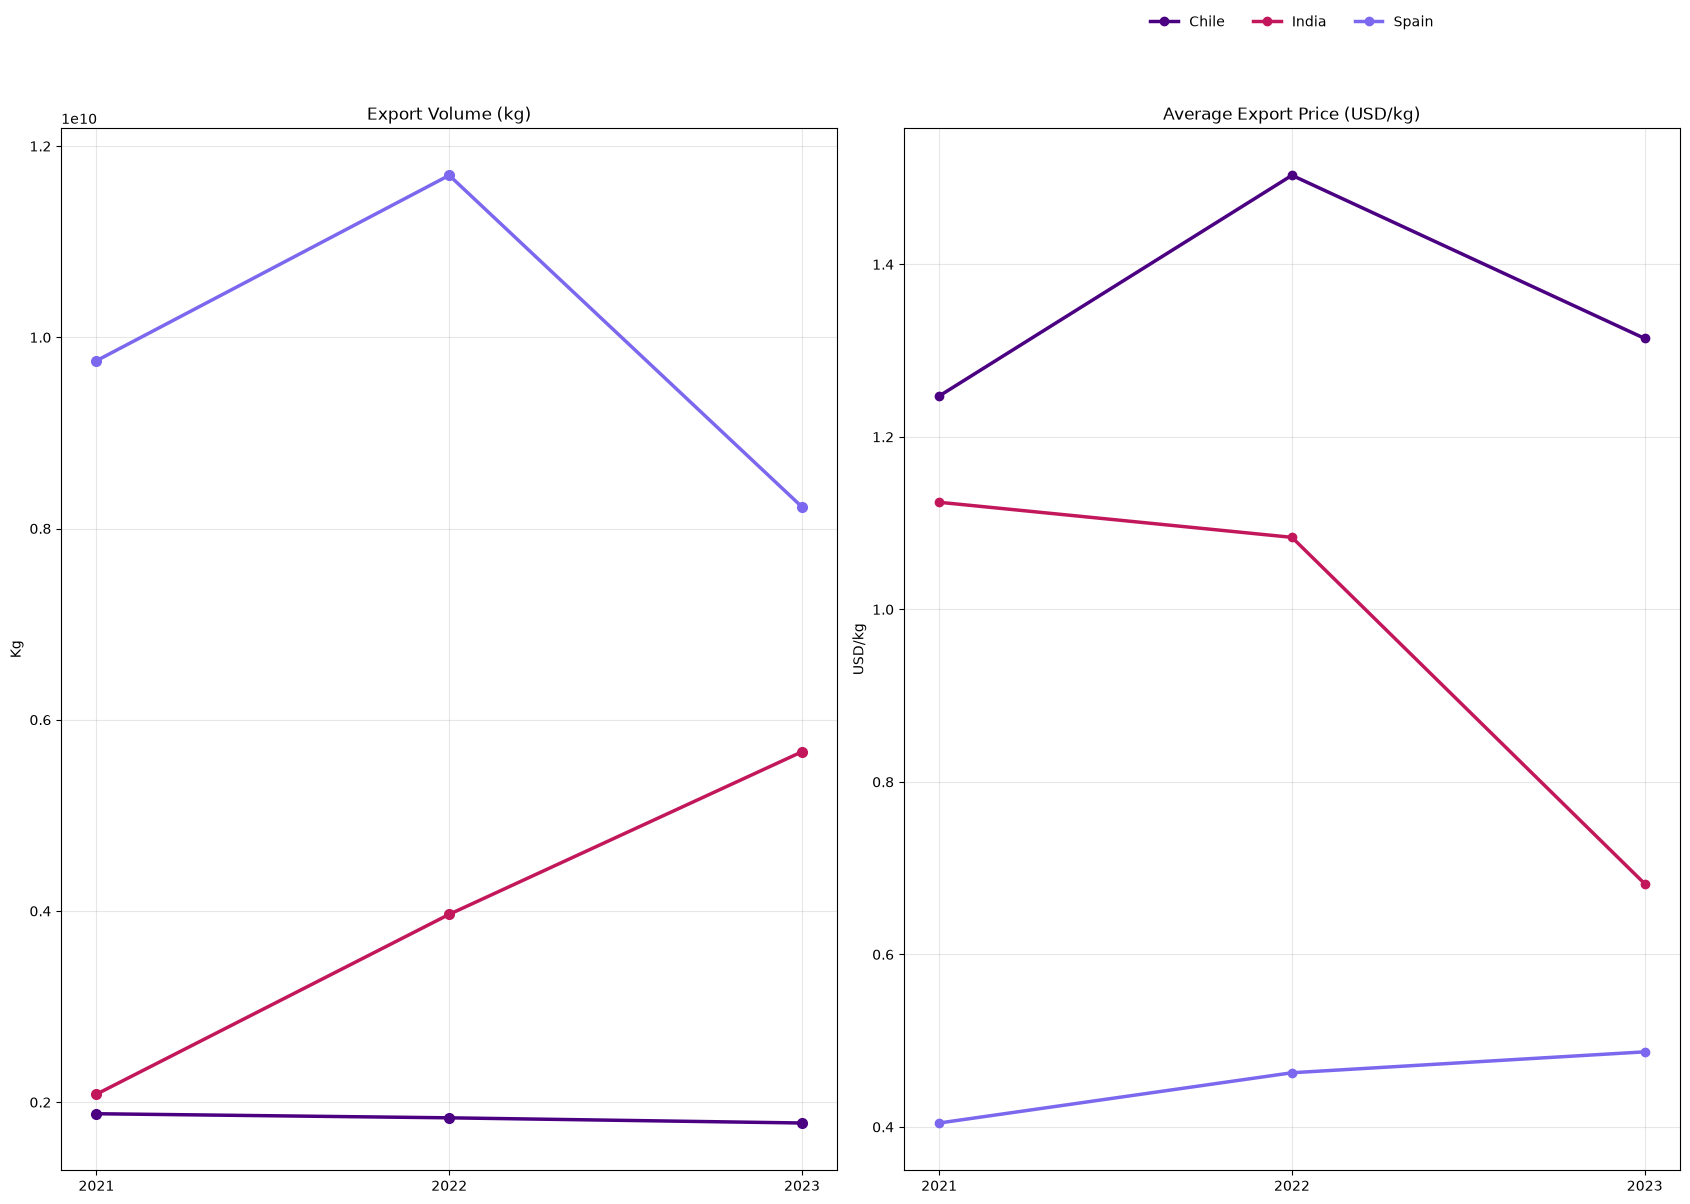

In [165]:
plot_categoria(plot_df, 'INTERMEDIATE GOODS (BI)')

**Net Weight**

Among the three countries analyzed, Spain accounted for the largest volume of Brazilian exports of intermediate goods throughout the entire period. However, after peaking in 2022, there was a significant decrease of approximately 29.7% in the net weight exported in 2023. In contrast, India showed continuous growth in export volume between 2021 and 2023, while Chile maintained a relatively stable volume over the three-year period.

**Average Price**

Regarding the average price per kilogram, both Chile and India recorded decreases in 2023. The decline was more pronounced in India, where the average price fell from approximately US$1.08/kg to US$0.68/kg (-37.1%). Chile, on the other hand, saw a more moderate decrease, from US$ 1.50/kg to US$ 1.31/kg (-12.6%). In contrast, Spain saw a slight increase in the average price over the period analyzed.

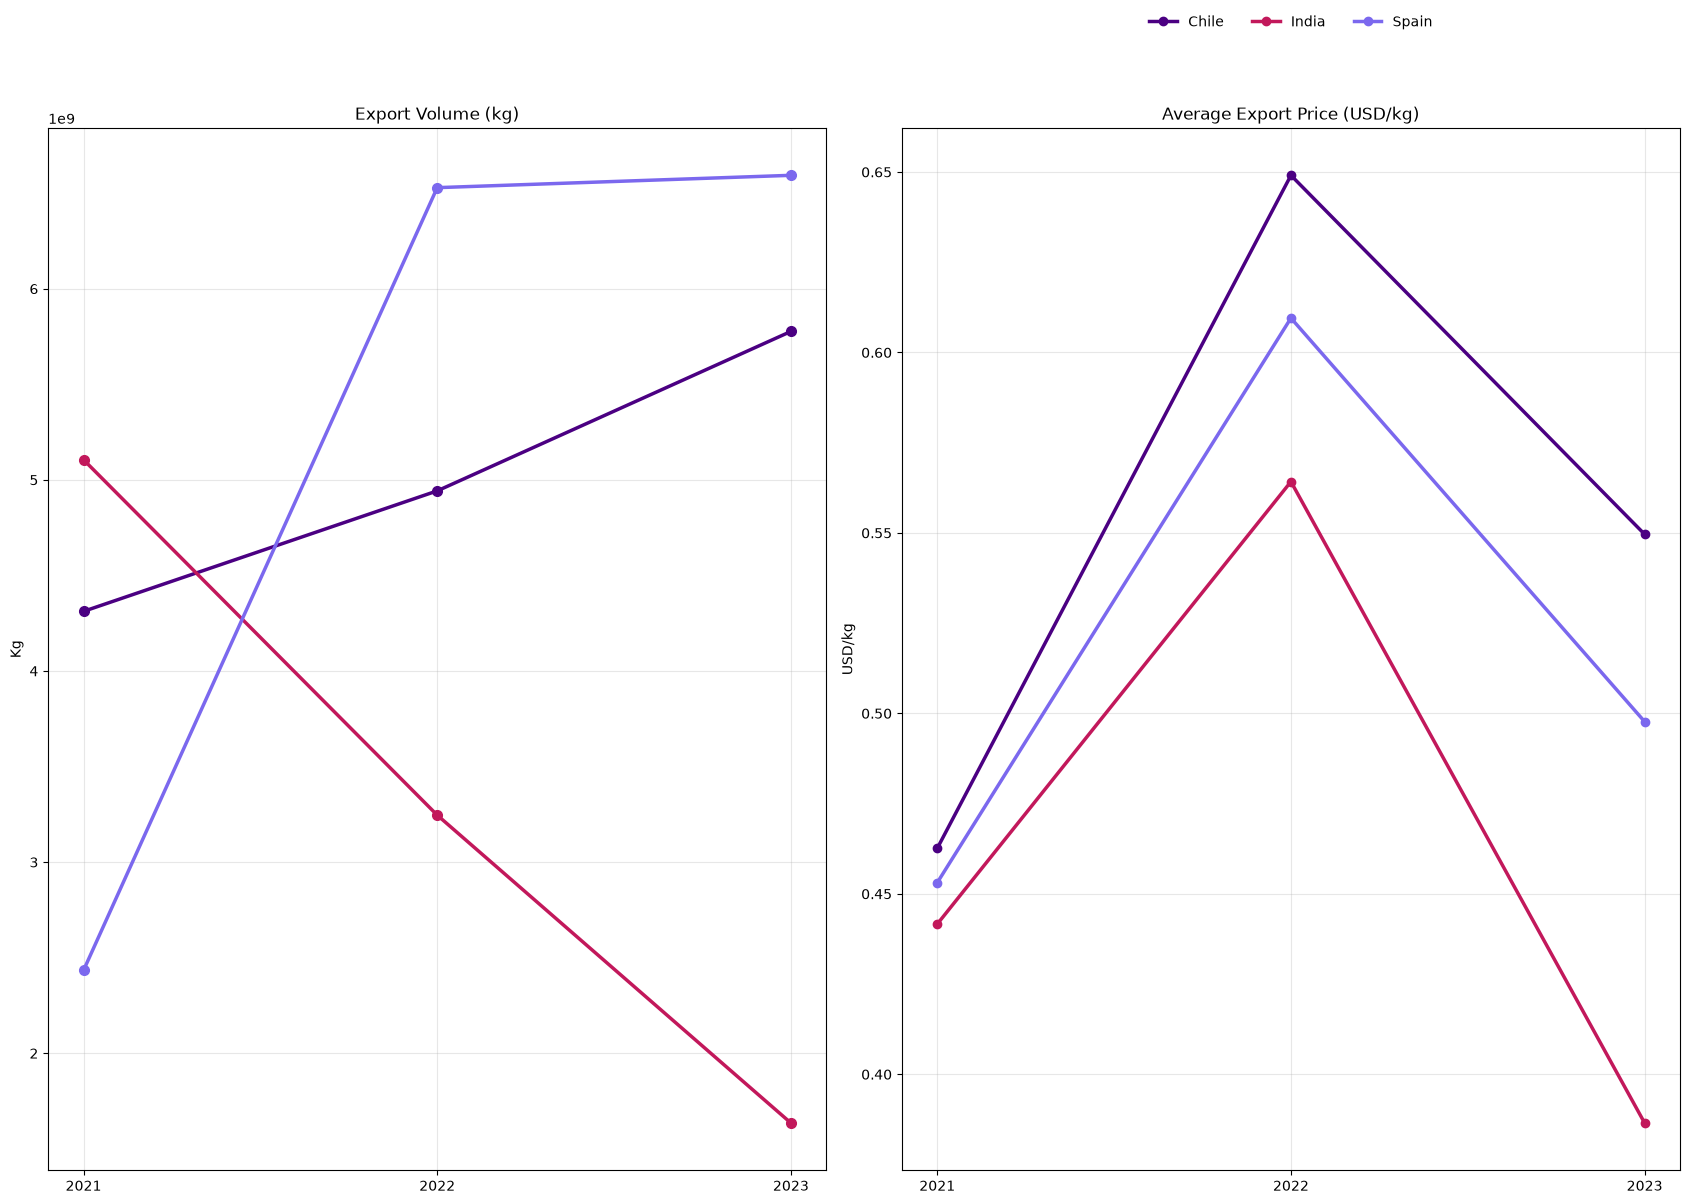

In [166]:
plot_categoria(plot_df, 'FUELS AND LUBRICANTS')

**Net Weight**

Among the three countries analyzed, Spain saw the largest increase in the volume of Brazilian fuel and lubricant exports between 2021 and 2022, rising from approximately 2.4 to 6.5 billion kg. Between 2022 and 2023, the volume remained virtually stable.Exports to India showed a steady decline in volume over the period, while Chile recorded steady growth between 2021 and 2023.

**Average Price**

Chile had the highest average price per kilogram throughout the entire period analyzed, followed by Spain and India. Between 2021 and 2022, the average price increased in all three markets. However, between 2022 and 2023, the average price decreased for all countries analyzed, with the sharpest decline occurring in India.

### **Main Insights**

Chile stands out primarily for changes in the volume of capital goods and consumer goods exported, but maintains relatively high average prices.
India shows significant growth in intermediate goods, though this is accompanied by a decline in the average price.
Spain shows varying trends depending on the category: significant growth in the average price of capital goods, an increase in the volume of fuels, and a significant decline in the volume of intermediate goods.

### **Recomendations**

#### Capital Goods

Among the three countries analyzed, Chile accounted for the largest volume of Brazilian capital goods exports over the period. However, following growth between 2021 and 2022 (+8.9%), there was a significant 35.7% decline in export volume in 2023. This trend warrants further investigation to identify possible changes in Chilean demand, in the competitiveness of Brazilian exports, or in other economic and trade factors that may have influenced this decline.

Spain showed the greatest volatility in average price among the three countries analyzed. Following a decline in 2022, the average price nearly quadrupled in 2023 compared to the previous year, reaching approximately US$ 33.7/kg. This trend may indicate changes in the profile of exported goods, with a greater share of higher-value-added products, or changes in the composition of the export basket.

#### Consumer Goods

Among the three countries analyzed, Chile accounted for the largest volume of Brazilian exports of consumer goods over the period. However, a decline in export volume was observed between 2021 and 2022, with no recovery in 2023. This trend suggests the need to investigate the factors that may have contributed to the decline in Chilean demand or to the reduced competitiveness of Brazilian exports in this market.

Regarding price, the average price fluctuated over the period, rising in 2022 and then returning to a level close to that observed in 2021. Thus, the main point of concern in this market appears to be related to the decline in export volume, rather than a consistent downward trend in prices.

#### Intermediate Goods

The continued growth in export volume to India was accompanied by a significant decline in the average price in 2023. This trend may indicate an expansion of exports driven primarily by an increase in the quantity shipped, while the average price per kilogram decreased.

Similarly, for Spain:
Although Spain saw a significant decline in export volume in 2023, the average price continued to rise, which may indicate a shift in the composition of exports or a greater share of higher-value-added products.

#### Fuels and Lubrificants

The continued decline in the volume exported to India, coupled with the drop in the average price in 2023, suggests the need to investigate the factors that have impacted this market, such as changes in demand, competitiveness, logistics costs, or conditions in the international fuel market.

The observed fluctuations in the average price should be interpreted with caution, since the fuel market is strongly influenced by external factors—such as international commodity prices, exchange rates, and geopolitical events—which were not taken into account in this analysis.